<a href="https://colab.research.google.com/github/pateld07/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. Regularization adds a penalty to the mean squared error so the model doesn’t use really large coefficients and overfit the data. It basically forces the model to stay simpler, which usually helps it do better on new, unseen data.
2. Regularization helps explore the bias-variance tradeoff by controlling how complex the model is. As the penalty increases, bias goes up and variance goes down, so we can pick a balance that gives the best performance.
3. LASSO uses an absolute value penalty and can shrink some coefficients all the way to zero, so it does feature selection. Ridge uses a squared penalty and just shrinks coefficients but keeps all variables in the model.
4. We usually scale variables like making them have mean 0 and standard deviation 1 before regularization. This is because the penalty depends on coefficient size, and scaling makes sure all variables are treated fairly.

5. The penalty α is usually chosen using cross-validation by trying different values and picking the one with the best validation performance. This helps avoid overfitting or underfitting.

6. When doing cross-validation, we do not include the penalty term in the MSE we evaluate. We only care about prediction error on new data, not the size of the coefficients.


**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?

The interaction between Mileage_Run and Age is negative. When both mileage and age increase, the price goes down even more.

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
Selected features:
Mileage_Run
Age
Mileage_Run²
Mileage_Run × Age
Mileage_Run × Age²
Age³

Proportion set to zero: 0.333, so about one-third of the features were removed by LASSO.

7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

Yes 1 coefficient increased

Yes Some variables change sign between linear regression and LASSO.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

df = pd.read_csv("./cars_hw (1).csv")

current_year = 2024
df["Age"] = current_year - df["Make_Year"]


X = df[["Mileage_Run", "Age"]]
y = df["Price"]

In [11]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [13]:
linreg = LinearRegression()
linreg.fit(X_scaled, y)

coefficients = pd.Series(linreg.coef_, index=feature_names)
print(coefficients)

Mileage_Run          6.686165e+05
Age                 -1.841941e+05
Mileage_Run^2       -1.494679e+05
Mileage_Run Age     -1.251592e+06
Age^2                2.156399e+05
Mileage_Run^3       -6.514490e+04
Mileage_Run^2 Age    2.833392e+05
Mileage_Run Age^2    5.280829e+05
Age^3               -1.389370e+05
dtype: float64


In [14]:
print("Interaction coefficient:", coefficients["Mileage_Run Age"])

Interaction coefficient: -1251592.3408260453


In [15]:
alphas = np.logspace(1, 3, 20)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=10000)
lasso.fit(X_scaled, y)

LassoCV(alphas=array([  10.        ,   12.74274986,   16.23776739,   20.69138081,
         26.36650899,   33.59818286,   42.81332399,   54.55594781,
         69.51927962,   88.58667904,  112.88378917,  143.84498883,
        183.29807108,  233.57214691,  297.63514416,  379.26901907,
        483.29302386,  615.84821107,  784.75997035, 1000.        ]),
        cv=20, max_iter=10000)

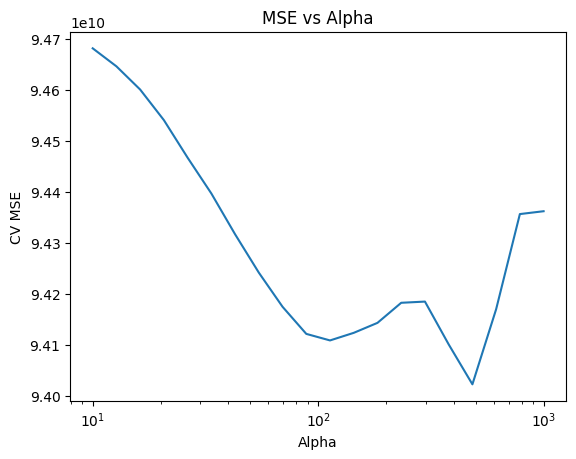

In [16]:
mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("CV MSE")
plt.title("MSE vs Alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 185708452846.75, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1496502935991.375, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1062651595526.5, tolerance: 66748451500.0
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective 

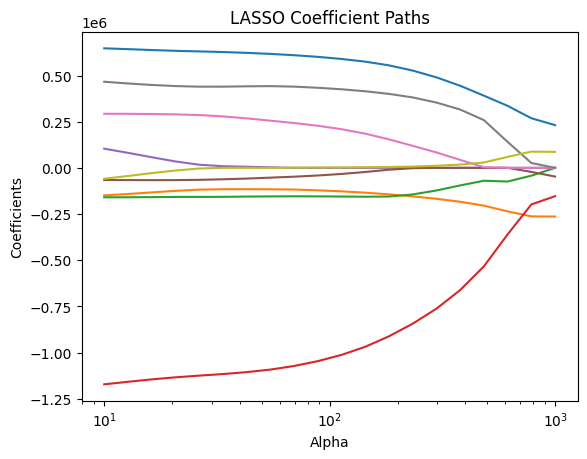

In [17]:
alphas_lasso, coefs, _ = lasso_path(X_scaled, y, alphas=alphas)

for i in range(coefs.shape[0]):
    plt.plot(alphas_lasso, coefs[i])

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Coefficients")
plt.title("LASSO Coefficient Paths")
plt.show()

In [18]:
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

print("Selected features:")
print(lasso_coefs[lasso_coefs != 0])

Selected features:
Mileage_Run          401025.259657
Age                 -194803.116695
Mileage_Run^2        -62539.290093
Mileage_Run Age     -578788.661090
Mileage_Run Age^2    292015.025679
Age^3                 19133.908573
dtype: float64


In [19]:
num_zero = np.sum(lasso_coefs == 0)
total = len(lasso_coefs)

print("Proportion zero:", num_zero / total)

Proportion zero: 0.3333333333333333


In [23]:
coefficients["Mileage_Run Age"]

np.float64(-1251592.3408260453)

In [22]:
lasso_coefs != 0

,0
Mileage_Run,True
Age,True
Mileage_Run^2,True
Mileage_Run Age,True
Age^2,False
Mileage_Run^3,False
Mileage_Run^2 Age,False
Mileage_Run Age^2,True
Age^3,True


In [24]:
num_zero / total

np.float64(0.3333333333333333)

In [27]:
comparison = pd.DataFrame({
    "Linear": coefficients,
    "LASSO": lasso_coefs
})

,0
Mileage_Run,False
Age,True
Mileage_Run^2,False
Mileage_Run Age,False
Age^2,False
Mileage_Run^3,False
Mileage_Run^2 Age,False
Mileage_Run Age^2,False
Age^3,False


In [28]:

abs(comparison["LASSO"]) > abs(comparison["Linear"])

,0
Mileage_Run,False
Age,True
Mileage_Run^2,False
Mileage_Run Age,False
Age^2,False
Mileage_Run^3,False
Mileage_Run^2 Age,False
Mileage_Run Age^2,False
Age^3,False


In [29]:
np.sign(comparison["Linear"]) != np.sign(comparison["LASSO"])

,0
Mileage_Run,False
Age,False
Mileage_Run^2,False
Mileage_Run Age,False
Age^2,True
Mileage_Run^3,True
Mileage_Run^2 Age,True
Mileage_Run Age^2,False
Age^3,True


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

Yes, there are some signs that seem weird at first. For example, age is positive, but age² is negative. Also, ejection_fraction is negative, but ejection_fraction² is positive. This seems confusing because it looks like the same variable is both helping and hurting at the same time.

The higher-order terms help the model capture curved relationships instead of forcing everything to be linear. So instead of saying “age always increases risk,” the model can say “age increases risk more at certain levels.”

Interactions also help because they show how variables work together, like how ejection fraction and creatinine might affect risk differently when combined.

But this happens because the model includes polynomial terms, so the relationship is not a straight line. Instead, the effect of a variable can change depending on its value, which is why the signs can flip.
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

LASSO simplified the model a lot and only kept the strongest predictors.

Yes, 1 coefficient increased in magnitude. This happens because when LASSO shrinks some coefficients to zero, it can make other ones slightly bigger to compensate.

Yes, a lot of them changed sign (24). This shows that the original linear regression model was kind of unstable, and LASSO changed the relationships to make the model more consistent.

The LASSO model makes more sense. The regular linear regression uses a ton of features, which can make it overfit and give weird results. LASSO fixes this by shrinking and removing features, so the model is more stable.

In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

df = pd.read_csv("./heart_failure_clinical_records_dataset.csv")

num_vars = ["age", "ejection_fraction", "serum_creatinine"]
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]

y = df["DEATH_EVENT"]

poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num = poly_num.fit_transform(df[num_vars])
num_feature_names = poly_num.get_feature_names_out(num_vars)

poly_cat = PolynomialFeatures(degree=4, include_bias=False, interaction_only=True)
X_cat = poly_cat.fit_transform(df[cat_vars])
cat_feature_names = poly_cat.get_feature_names_out(cat_vars)

X = np.hstack([X_num, X_cat])
feature_names = list(num_feature_names) + list(cat_feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_scaled, y)

coefficients = pd.Series(linreg.coef_, index=feature_names)

print(coefficients.sort_values(key=np.abs, ascending=False))

age^2                                          -3.717758
ejection_fraction^2                             3.352956
serum_creatinine^2                             -2.640240
ejection_fraction serum_creatinine              2.569764
ejection_fraction                              -2.062277
age^3                                           1.963124
age serum_creatinine                            1.707056
age ejection_fraction serum_creatinine         -1.626996
age                                             1.619432
age serum_creatinine^2                          1.444075
ejection_fraction^3                            -1.245337
ejection_fraction serum_creatinine^2            1.189516
ejection_fraction^2 serum_creatinine           -1.151378
age^2 ejection_fraction                         1.054408
age ejection_fraction                          -0.800726
serum_creatinine                               -0.757092
age^2 serum_creatinine                         -0.679042
diabetes smoking               

In [32]:
from sklearn.linear_model import LassoCV

alphas = np.logspace(-5, 5, 30)

lasso = LassoCV(alphas=alphas, cv=20, max_iter=100000, random_state=0)
lasso.fit(X_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

print("Best alpha:", lasso.alpha_)
print(lasso_coefs.sort_values(key=np.abs, ascending=False))

Best alpha: 0.005736152510448681
ejection_fraction                              -0.328773
ejection_fraction^3                             0.197782
age^3                                           0.115926
serum_creatinine                                0.110126
serum_creatinine^3                             -0.047913
anaemia diabetes high_blood_pressure smoking   -0.044382
ejection_fraction^2 serum_creatinine            0.042528
diabetes high_blood_pressure                    0.029299
diabetes smoking                                0.027214
high_blood_pressure smoking                     0.023275
smoking                                        -0.023170
anaemia high_blood_pressure smoking             0.020376
anaemia                                         0.009818
anaemia diabetes                                0.007142
age                                            -0.000000
age serum_creatinine                            0.000000
age ejection_fraction                          -0.00000

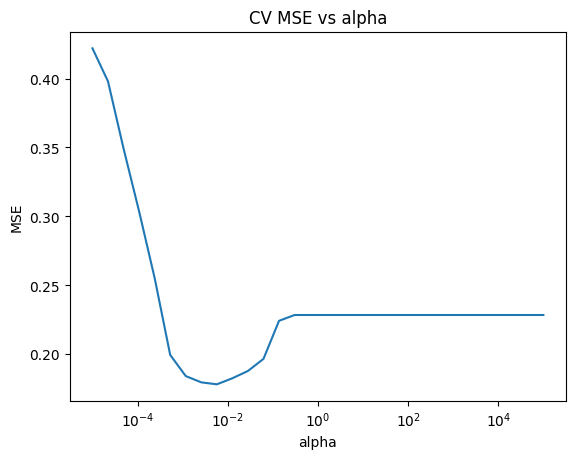

In [33]:
import matplotlib.pyplot as plt

mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.plot(lasso.alphas_, mean_mse)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("MSE")
plt.title("CV MSE vs alpha")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.240966677519026, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.23200615415949244, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.589936834368437, tolerance: 0.009600000000000001
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Con

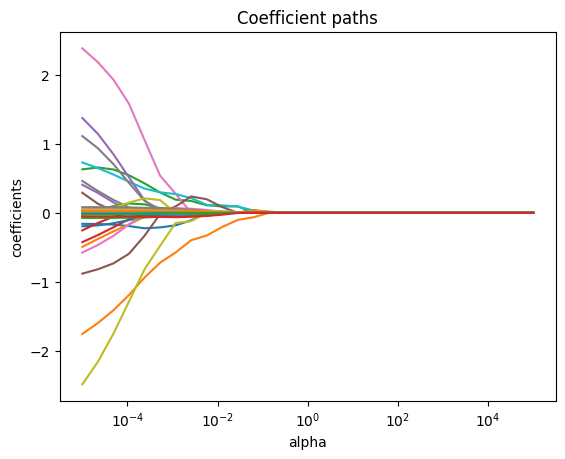

In [34]:
from sklearn.linear_model import lasso_path

alphas_path, coefs_path, _ = lasso_path(X_scaled, y, alphas=alphas)

for i in range(coefs_path.shape[0]):
    plt.plot(alphas_path, coefs_path[i])

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("coefficients")
plt.title("Coefficient paths")
plt.show()

In [35]:
selected_features = lasso_coefs[lasso_coefs != 0]
print(selected_features)

num_zero = np.sum(lasso_coefs == 0)
total = len(lasso_coefs)

print("Proportion zero:", num_zero / total)

ejection_fraction                              -0.328773
serum_creatinine                                0.110126
age^3                                           0.115926
ejection_fraction^3                             0.197782
ejection_fraction^2 serum_creatinine            0.042528
serum_creatinine^3                             -0.047913
anaemia                                         0.009818
smoking                                        -0.023170
anaemia diabetes                                0.007142
diabetes high_blood_pressure                    0.029299
diabetes smoking                                0.027214
high_blood_pressure smoking                     0.023275
anaemia high_blood_pressure smoking             0.020376
anaemia diabetes high_blood_pressure smoking   -0.044382
dtype: float64
Proportion zero: 0.5882352941176471


In [36]:
comparison = pd.DataFrame({
    "Linear": coefficients,
    "LASSO": lasso_coefs
})

print(comparison)

print("Magnitude increased:")
print((abs(comparison["LASSO"]) > abs(comparison["Linear"])).sum())

print("Sign changes:")
print((np.sign(comparison["LASSO"]) != np.sign(comparison["Linear"])).sum())

                                                Linear     LASSO
age                                           1.619432 -0.000000
ejection_fraction                            -2.062277 -0.328773
serum_creatinine                             -0.757092  0.110126
age^2                                        -3.717758  0.000000
age ejection_fraction                        -0.800726 -0.000000
age serum_creatinine                          1.707056  0.000000
ejection_fraction^2                           3.352956  0.000000
ejection_fraction serum_creatinine            2.569764  0.000000
serum_creatinine^2                           -2.640240 -0.000000
age^3                                         1.963124  0.115926
age^2 ejection_fraction                       1.054408  0.000000
age^2 serum_creatinine                       -0.679042  0.000000
age ejection_fraction^2                      -0.066433  0.000000
age ejection_fraction serum_creatinine       -1.626996  0.000000
age serum_creatinine^2   

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

The objective function is the sum of squared errors plus a penalty on the slope coefficient. So we take the usual error between predicted and actual values and add alpha times the square of the slope.

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

After solving the equations, the intercept b0 equals 0 because the data was mean-centered.The slope b1 is equal to the sum of x times y divided by the sum of x squared plus alpha.

3. How does increasing $\alpha$ change the slope coefficient?

As alpha increases, the slope gets smaller and moves closer to zero. This means the line becomes flatter. So a bigger alpha causes more shrinkage.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

The challenge with LASSO is that the absolute value function is not differentiable at 0, so we cannot take a normal derivative like we did for ridge regression. Instead, we have to consider different cases depending on whether the slope is positive, negative, or zero.
It is optimal to set the slope equal to 0 when the relationship between x and y is not strong enough to overcome the penalty. In other words, if x and y are only weakly related, LASSO will shrink the coefficient all the way to zero.